In [ ]:
N_DOCS               = 3
FORCE_FULL_PRECISION = False
FORCE_4BIT           = False
SHOW_FIRST_PAGE      = True
RUN_ON_REAL_PDF      = False
REAL_PDF_URL         = ""
REAL_PDF_PAGES       = "0-1"
PIN_PILLOW           = True
PILLOW_VERSION       = "11.3.0"

import os, sys, subprocess, json, re, time, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def pip(*pkgs, upgrade=False):
    """Install without invoking a shell (so '[hf]' is never glob-expanded)."""
    args = [sys.executable, "-m", "pip", "install", "-q"] + (["-U"] if upgrade else []) + list(pkgs)
    print("  pip install", *pkgs)
    subprocess.run(args, check=False)


print("STEP 1/7 · Installing lift + light dependencies (first run is the slow one)…")
pip("reportlab", "pypdfium2", "pandas", "matplotlib")
pip("lift-pdf[hf]")
pip("bitsandbytes", "accelerate", upgrade=True)






if PIN_PILLOW:
    pip(f"pillow=={PILLOW_VERSION}")
    if "PIL" in sys.modules:
        import PIL
        if getattr(PIL, "__version__", "") != PILLOW_VERSION:
            print(f"     Pinned Pillow {PILLOW_VERSION} on disk, but a stale "
                  f"{getattr(PIL, '__version__', '?')} is loaded in memory — restarting runtime.")
            print("     Just re-run the cell(s) after Colab reconnects.")
            os.kill(os.getpid(), 9)


print("     …install finished.\n")

import torch

In [ ]:
def detect_gpu():
    if not torch.cuda.is_available():
        raise SystemExit(
            "\n✗ No CUDA GPU found. In Colab: Runtime ▸ Change runtime type ▸ GPU "
            "(A100 is best; L4/T4 also work).\n"
        )
    p  = torch.cuda.get_device_properties(0)
    cc = torch.cuda.get_device_capability(0)
    return p.name, p.total_memory / 1e9, cc

def enable_4bit(compute_dtype):
    """Load lift's weights in 4-bit NF4 whatever transformers Auto* class it uses internally."""
    import inspect, functools, transformers
    from transformers import BitsAndBytesConfig
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )

    def patch(cls):
        try:
            cm   = inspect.getattr_static(cls, "from_pretrained")
            orig = cm.__func__ if isinstance(cm, (classmethod, staticmethod)) else cm
        except Exception:
            return

        @functools.wraps(orig)
        def inner(cls_, *args, **kwargs):
            kwargs.setdefault("quantization_config", bnb)
            kwargs.setdefault("device_map", {"": 0})
            model = orig(cls_, *args, **kwargs)
            try:
                model.to   = lambda *a, **k: model
                model.cuda = lambda *a, **k: model
            except Exception:
                pass
            return model

        cls.from_pretrained = classmethod(inner)

    for name in ["AutoModelForImageTextToText", "AutoModelForMultimodalLM",
                 "AutoModelForVision2Seq", "AutoModelForCausalLM", "AutoModel"]:
        c = getattr(transformers, name, None)
        if c is not None:
            patch(c)
    try:
        from transformers.modeling_utils import PreTrainedModel
        patch(PreTrainedModel)
    except Exception:
        pass

print("STEP 2/7 · Preparing the model backend…")
gpu_name, vram, cc = detect_gpu()
use_4bit      = FORCE_4BIT or (vram < 34 and not FORCE_FULL_PRECISION)
compute_dtype = torch.bfloat16 if cc[0] >= 8 else torch.float16
print(f"     GPU: {gpu_name} | ~{vram:.0f} GB | compute capability {cc[0]}.{cc[1]}")
print(f"     Load mode: {'4-bit NF4' if use_4bit else 'full bf16'} (compute dtype {compute_dtype})")

os.environ.setdefault("TORCH_DEVICE", "cuda:0")
os.environ.setdefault("MODEL_CHECKPOINT", "datalab-to/lift")
if use_4bit:
    enable_4bit(compute_dtype)

from lift import extract
from lift.model import InferenceManager

print("     Loading lift weights (≈20 GB download on first run)…")
_t = time.time()
MODEL = InferenceManager(method="hf")
print(f"     ✓ model ready in {time.time() - _t:.0f}s\n")

def run_lift(pdf_path, schema, page_range=None):
    kw = {"model": MODEL}
    if page_range:
        kw["page_range"] = page_range
    result = extract(pdf_path, schema, **kw)
    return getattr(result, "extraction", None)

In [ ]:
DOCS = [
    dict(
        invoice_number="INV-2026-0412",
        invoice_date="2026-05-04", due_date="2026-06-03",
        vendor_name="Cloudworks Inc.",
        vendor_address="500 Market St, Suite 900, San Francisco, CA 94105, USA",
        bill_to_name="Acme Robotics LLC",
        bill_to_address="12 Foundry Rd, Pittsburgh, PA 15222, USA",
        ship_to_name="Acme Robotics — Warehouse 4",
        ship_to_address="88 Dockside Blvd, Newark, NJ 07114, USA",
        po_number=None,
        discount_amount=None,
        currency_code="USD", currency_symbol="$",
        tax_rate=0.085,
        amount_paid=0.00,
        line_items=[
            ("Cloud Compute — Standard tier (monthly)", 3, 240.00),
            ("Object Storage — 2 TB", 1, 46.00),
            ("Priority Support add-on", 1, 99.00),
        ],
        notes="Payment due within 30 days. Late payments accrue 1.5% monthly interest.",
    ),
    dict(
        invoice_number="INV-ND-2026-118",
        invoice_date="2026-04-18", due_date="2026-05-18",
        vendor_name="Nordic Design Studio Oy",
        vendor_address="Eteläranta 12, 00130 Helsinki, Finland",
        bill_to_name="Helsinki Media Oy",
        bill_to_address="Mannerheimintie 4, 00100 Helsinki, Finland",
        ship_to_name=None, ship_to_address=None,
        po_number="PO-HM-5589",
        discount_amount=785.00,
        currency_code="EUR", currency_symbol="€",
        tax_rate=0.24,
        amount_paid=8760.60,
        line_items=[
            ("Brand identity design package", 1, 4200.00),
            ("Web UI design — 12 screens", 12, 180.00),
            ("Custom illustration set", 1, 850.00),
            ("Design-system documentation", 1, 640.00),
        ],
        notes="Paid in full — thank you. All amounts in EUR.",
    ),
    dict(
        invoice_number="INV-BR-4471",
        invoice_date="2026-06-01", due_date="2026-07-15",
        vendor_name="BuildRight Contractors Inc.",
        vendor_address="740 Industrial Way, Austin, TX 78744, USA",
        bill_to_name="Sunrise Property Group",
        bill_to_address="9 Lakeview Terrace, Austin, TX 78703, USA",
        ship_to_name="Sunrise Property Group — Lot 14 site office",
        ship_to_address="Parcel 14, Mesa Ridge Development, Austin, TX 78737, USA",
        po_number="PO-SPG-2211",
        discount_amount=None,
        currency_code="USD", currency_symbol="$",
        tax_rate=0.07,
        amount_paid=15000.00,
        line_items=[
            ("Site preparation and grading", 1, 18500.00),
            ("Foundation concrete pour (Phase 1)", 1, 27400.00),
        ],
        notes="A 15,000 USD deposit has been received. Remaining balance due by the date above.",
    ),
][:N_DOCS]

def compute(d):
    """Derive every money figure once, so PDF text and ground truth are guaranteed identical."""
    items = [(desc, q, up, round(q * up, 2)) for (desc, q, up) in d["line_items"]]
    subtotal = round(sum(t for *_, t in items), 2)
    disc     = d.get("discount_amount")
    taxable  = round(subtotal - (disc or 0.0), 2)
    tax      = round(taxable * d["tax_rate"], 2)
    total    = round(taxable + tax, 2)
    paid     = round(d.get("amount_paid", 0.0), 2)
    balance  = round(total - paid, 2)
    return dict(items=items, subtotal=subtotal, discount=disc, tax=tax,
                total=total, amount_paid=paid, balance=balance, is_paid=(balance <= 0.005))

def ground_truth(d):
    """Reshape raw inputs + computed totals into the exact JSON shape our schema asks for."""
    c = compute(d)
    return {
        "invoice_number": d["invoice_number"],
        "invoice_date": d["invoice_date"],
        "due_date": d["due_date"],
        "vendor": {"name": d["vendor_name"], "address": d["vendor_address"]},
        "customer_name": d["bill_to_name"],
        "purchase_order_number": d.get("po_number"),
        "currency": d["currency_code"],
        "line_items": [{"description": desc, "quantity": q,
                        "unit_price": up, "line_total": t} for (desc, q, up, t) in c["items"]],
        "subtotal": c["subtotal"],
        "discount_amount": c["discount"],
        "tax_amount": c["tax"],
        "total_amount": c["total"],
        "amount_paid": c["amount_paid"],
        "balance_due": c["balance"],
        "is_paid": c["is_paid"],
    }

In [ ]:
def render_pdf(d, path):
    """Draw a realistic one-page invoice: header, meta, bill/ship, line items, totals, payment."""
    from reportlab.lib.pagesizes import LETTER
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.lib import colors
    from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                    Table, TableStyle)

    c   = compute(d)
    sym = d["currency_symbol"]
    def money(x): return f"{sym}{x:,.2f}"

    ss   = getSampleStyleSheet()
    H1   = ParagraphStyle("H1",   parent=ss["Title"],    fontSize=18, leading=22, spaceAfter=2)
    SMALL= ParagraphStyle("SM",   parent=ss["Normal"],   fontSize=8.5, textColor=colors.grey, leading=11)
    LBL  = ParagraphStyle("LBL",  parent=ss["Normal"],   fontSize=8.5, textColor=colors.HexColor("#2b3a67"),
                          spaceAfter=1, fontName="Helvetica-Bold")
    BODY = ParagraphStyle("BODY", parent=ss["Normal"],   fontSize=9.5, leading=13)
    RIGHT= ParagraphStyle("R",    parent=ss["Normal"],   fontSize=16, leading=18, alignment=2,
                          textColor=colors.HexColor("#2b3a67"), fontName="Helvetica-Bold")

    story = []

    head = Table([[
        [Paragraph(d["vendor_name"], H1), Paragraph(d["vendor_address"], SMALL)],
        [Paragraph("INVOICE", RIGHT),
         Paragraph(f"{d['invoice_number']}", ParagraphStyle('n', parent=SMALL, alignment=2, fontSize=9.5))],
    ]], colWidths=[4.2 * inch, 2.8 * inch])
    head.setStyle(TableStyle([("VALIGN", (0, 0), (-1, -1), "TOP")]))
    story += [head, Spacer(1, 10)]


    meta_rows = [["Invoice date", d["invoice_date"], "Due date", d["due_date"]]]
    if d.get("po_number"):
        meta_rows.append(["PO number", d["po_number"], "Currency", d["currency_code"]])
    else:
        meta_rows.append(["Currency", d["currency_code"], "", ""])
    meta = Table(meta_rows, colWidths=[1.3 * inch, 2.2 * inch, 1.3 * inch, 2.2 * inch])
    meta.setStyle(TableStyle([
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("TEXTCOLOR", (0, 0), (0, -1), colors.HexColor("#2b3a67")),
        ("TEXTCOLOR", (2, 0), (2, -1), colors.HexColor("#2b3a67")),
        ("FONTNAME", (0, 0), (0, -1), "Helvetica-Bold"),
        ("FONTNAME", (2, 0), (2, -1), "Helvetica-Bold"),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 3), ("TOPPADDING", (0, 0), (-1, -1), 3)]))
    story += [meta, Spacer(1, 12)]


    bill = [Paragraph("BILL TO", LBL), Paragraph(d["bill_to_name"], BODY),
            Paragraph(d["bill_to_address"], SMALL)]
    if d.get("ship_to_name"):
        ship = [Paragraph("SHIP TO", LBL), Paragraph(d["ship_to_name"], BODY),
                Paragraph(d["ship_to_address"], SMALL)]
    else:
        ship = [Paragraph("SHIP TO", LBL), Paragraph("Same as billing address", SMALL)]
    parties = Table([[bill, ship]], colWidths=[3.5 * inch, 3.5 * inch])
    parties.setStyle(TableStyle([("VALIGN", (0, 0), (-1, -1), "TOP"),
                                 ("LEFTPADDING", (0, 0), (-1, -1), 0)]))
    story += [parties, Spacer(1, 14)]


    rows = [["Description", "Qty", "Unit price", "Amount"]]
    for (desc, q, up, t) in c["items"]:
        rows.append([desc, str(q), money(up), money(t)])
    items_tbl = Table(rows, colWidths=[3.5 * inch, 0.7 * inch, 1.4 * inch, 1.4 * inch])
    items_tbl.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2b3a67")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("ALIGN", (1, 0), (-1, -1), "RIGHT"),
        ("GRID", (0, 0), (-1, -1), 0.4, colors.HexColor("#cdd3e6")),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#eef1f8")]),
        ("LEFTPADDING", (0, 0), (-1, -1), 8), ("TOPPADDING", (0, 0), (-1, -1), 5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 5)]))
    story += [items_tbl, Spacer(1, 10)]


    tot_rows = [["Subtotal", money(c["subtotal"])]]
    if c["discount"]:
        tot_rows.append(["Discount", "-" + money(c["discount"])])
    tot_rows.append([f"Tax ({d['tax_rate']*100:.1f}%)", money(c["tax"])])
    tot_rows.append(["TOTAL", money(c["total"])])
    totals = Table(tot_rows, colWidths=[1.6 * inch, 1.4 * inch], hAlign="RIGHT")
    totals.setStyle(TableStyle([
        ("FONTSIZE", (0, 0), (-1, -1), 10),
        ("ALIGN", (0, 0), (-1, -1), "RIGHT"),
        ("LINEABOVE", (0, -1), (-1, -1), 1.0, colors.HexColor("#2b3a67")),
        ("FONTNAME", (0, -1), (-1, -1), "Helvetica-Bold"),
        ("TEXTCOLOR", (0, -1), (-1, -1), colors.HexColor("#2b3a67")),
        ("TOPPADDING", (0, 0), (-1, -1), 3), ("BOTTOMPADDING", (0, 0), (-1, -1), 3)]))
    story += [totals, Spacer(1, 8)]


    pay_rows = [["Amount paid", money(c["amount_paid"])],
                ["Balance due", money(c["balance"])]]
    pay = Table(pay_rows, colWidths=[1.6 * inch, 1.4 * inch], hAlign="RIGHT")
    due_color = colors.HexColor("#1b7a3d") if c["is_paid"] else colors.HexColor("#7a2e2e")
    pay.setStyle(TableStyle([
        ("FONTSIZE", (0, 0), (-1, -1), 10),
        ("ALIGN", (0, 0), (-1, -1), "RIGHT"),
        ("FONTNAME", (0, 1), (-1, 1), "Helvetica-Bold"),
        ("TEXTCOLOR", (0, 1), (-1, 1), due_color),
        ("TOPPADDING", (0, 0), (-1, -1), 2), ("BOTTOMPADDING", (0, 0), (-1, -1), 2)]))
    status = "PAID IN FULL" if c["is_paid"] else "BALANCE DUE"
    story += [pay, Spacer(1, 6),
              Paragraph(f"<b>Status:</b> {status}", BODY), Spacer(1, 16),
              Paragraph("Notes", LBL), Paragraph(d["notes"], BODY)]

    SimpleDocTemplate(path, pagesize=LETTER,
                      topMargin=0.7 * inch, bottomMargin=0.7 * inch,
                      leftMargin=0.8 * inch, rightMargin=0.8 * inch).build(story)

print("STEP 3/7 · Generating synthetic invoice PDFs…")
CORPUS = []
for i, d in enumerate(DOCS):
    path = f"/content/invoice_{i}.pdf" if os.path.isdir("/content") else f"invoice_{i}.pdf"
    render_pdf(d, path)
    CORPUS.append((d, ground_truth(d), path))
    print(f"     ✓ {os.path.basename(path)}  —  {d['vendor_name']} → {d['bill_to_name']}")
print()


if SHOW_FIRST_PAGE:
    try:
        import pypdfium2 as pdfium, matplotlib.pyplot as plt
        pg  = pdfium.PdfDocument(CORPUS[0][2])[0]
        img = pg.render(scale=2.0).to_pil()
        plt.figure(figsize=(6.4, 8.3)); plt.imshow(img); plt.axis("off")
        plt.title("What lift reads — page 1 of invoice_0.pdf", fontsize=10); plt.show()
    except Exception as e:
        print("     page preview skipped:", e, "\n")

In [ ]:
SCHEMA = {
    "type": "object",
    "properties": {
        "invoice_number": {"type": "string", "description": "The invoice's unique identifier / number"},
        "invoice_date":   {"type": "string", "description": "Date the invoice was issued (as printed)"},
        "due_date":       {"type": "string", "description": "Date payment is due"},
        "vendor": {
            "type": "object",
            "description": "The party that ISSUED the invoice (the seller / supplier)",
            "properties": {
                "name":    {"type": "string"},
                "address": {"type": "string"},
            }},
        "customer_name": {"type": "string",
                          "description": "The party the invoice is billed TO (the 'Bill To' party) — "
                                         "not the vendor, and not the 'Ship To' party if it differs"},
        "purchase_order_number": {"type": "string",
                                  "description": "The PO number referenced on the invoice. "
                                                 "Return null if no purchase-order number appears"},
        "currency": {"type": "string",
                     "description": "ISO 4217 currency code of the amounts, e.g. USD or EUR"},
        "line_items": {
            "type": "array",
            "description": "Every billed line item, in order",
            "items": {"type": "object", "properties": {
                "description": {"type": "string"},
                "quantity":    {"type": "number"},
                "unit_price":  {"type": "number"},
                "line_total":  {"type": "number", "description": "quantity × unit_price for this line"},
            }}},
        "subtotal":        {"type": "number", "description": "Sum of line totals BEFORE tax and discount"},
        "discount_amount": {"type": "number",
                            "description": "Total discount applied. Return null if no discount is shown"},
        "tax_amount":      {"type": "number", "description": "Total tax / VAT charged"},
        "total_amount":    {"type": "number",
                            "description": "The grand total the customer owes, AFTER tax and any discount — "
                                           "NOT the pre-tax subtotal and NOT the tax line"},
        "amount_paid":     {"type": "number", "description": "Amount already paid deposits included"},
        "balance_due":     {"type": "number", "description": "Outstanding balance still owed"},
        "is_paid":         {"type": "boolean",
                            "description": "true ONLY if the balance due is zero. A partial payment or "
                                           "deposit with a remaining balance does NOT count as paid"},
    },
    "required": ["invoice_number", "total_amount", "vendor"],
}


def _norm(s):
    return re.sub(r"\s+", " ", str(s).strip().lower()).strip(" .,:;/")

def _num(x):
    try:    return float(str(x).replace("%", "").replace(",", "").replace("$", "").replace("€", "").strip())
    except Exception: return None

def leaf_equal(gt, pr):
    if gt is None and pr is None:                       return True
    if gt is None or pr is None:                        return False
    if isinstance(gt, bool) or isinstance(pr, bool):    return bool(gt) == bool(pr)
    a, b = _num(gt), _num(pr)
    if a is not None and b is not None:
        return abs(a - b) < 1e-6 if b == 0 else abs(a - b) / max(abs(a), abs(b)) < 5e-3
    return _norm(gt) == _norm(pr)

def flatten(o, prefix=""):
    out = {}
    if isinstance(o, dict):
        for k, v in o.items():
            out.update(flatten(v, f"{prefix}.{k}" if prefix else k))
    elif isinstance(o, list):
        for i, v in enumerate(o):
            out.update(flatten(v, f"{prefix}[{i}]"))
    else:
        out[prefix] = o
    return out

def score(gt, pred):
    fg, fp = flatten(gt), flatten(pred or {})
    rows, correct = [], 0
    for key, gv in fg.items():
        present = key in fp
        pv = fp.get(key)
        ok = (gv is None and (not present or pv is None)) or (present and leaf_equal(gv, pv))
        correct += int(ok)
        rows.append((key, gv, (pv if present else None), ok))
    return (correct / len(fg) if fg else 0.0), rows

In [ ]:
print("STEP 4/7 · Extracting with lift and scoring against ground truth…\n")
results = []
for i, (src, gt, path) in enumerate(CORPUS):
    t0 = time.time()
    pred = run_lift(path, SCHEMA)
    dt = time.time() - t0
    acc, rows = score(gt, pred)
    results.append(dict(src=src, gt=gt, pred=pred, acc=acc, rows=rows, seconds=dt))
    print(f"     invoice {i} · {src['vendor_name']:<28} field accuracy {acc*100:5.1f}%   ({dt:.1f}s)")


r0 = results[0]
print("\n" + "=" * 90)
print(f"DETAILED VIEW · invoice 0 · {r0['src']['vendor_name']} → {r0['src']['bill_to_name']}")
print("=" * 90)
print("Raw JSON lift returned guaranteed to match the schema shape:\n")
print(json.dumps(r0["pred"], indent=2, ensure_ascii=False))

import pandas as pd
pd.set_option("display.max_colwidth", 46)
pd.set_option("display.width", 120)
grade = pd.DataFrame([{"field": k,
                       "ground_truth": ("∅ null" if g is None else g),
                       "lift_predicted": ("∅ null" if p is None else p),
                       "✓": "✓" if ok else "✗"}
                      for (k, g, p, ok) in r0["rows"]])
print("\nField-by-field grade:\n")
print(grade.to_string(index=False))

print("\nWhat to look for:")
print("  • total_amount should be the AFTER-TAX grand total, not the subtotal — the distractor test.")
print("  • customer_name should be the BILL-TO party, not the different SHIP-TO warehouse.")
print("  • purchase_order_number and discount_amount should be ∅ null: invoice 0 has neither.")
print("  • on invoice 2, is_paid must be False — a $15,000 deposit is shown but a balance remains.")


print("\n" + "=" * 90)

STEP 1/7 · Installing lift + light dependencies (first run is the slow one)…
  pip install reportlab pypdfium2 pandas matplotlib
  pip install lift-pdf[hf]
  pip install bitsandbytes accelerate
  pip install pillow==11.3.0
     …install finished.

STEP 2/7 · Preparing the model backend…
     GPU: Tesla T4 | ~16 GB | compute capability 7.5
     Load mode: 4-bit NF4 (compute dtype torch.float16)
     Loading lift weights (≈20 GB download on first run)…


config.json:   0%|          | 0.00/2.78k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/19.3G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

     ✓ model ready in 419s

STEP 3/7 · Generating synthetic invoice PDFs…
     ✓ invoice_0.pdf  —  Cloudworks Inc. → Acme Robotics LLC
     ✓ invoice_1.pdf  —  Nordic Design Studio Oy → Helsinki Media Oy
     ✓ invoice_2.pdf  —  BuildRight Contractors Inc. → Sunrise Property Group



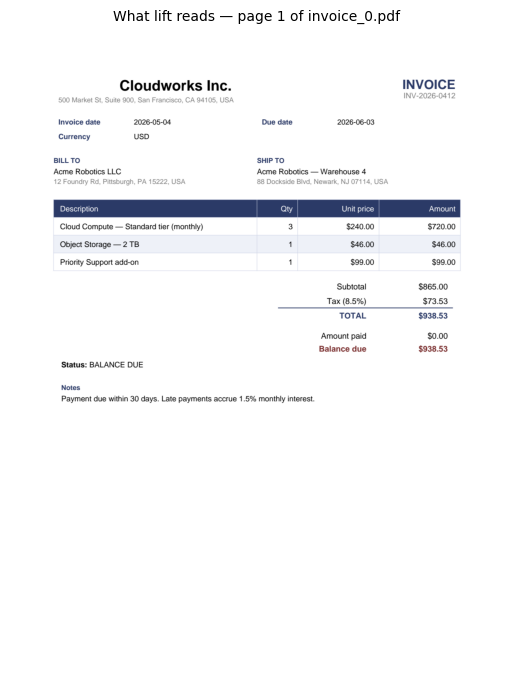

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


STEP 4/7 · Extracting with lift and scoring against ground truth…



[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


     invoice 0 · Cloudworks Inc.              field accuracy 100.0%   (76.8s)


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


     invoice 1 · Nordic Design Studio Oy      field accuracy 100.0%   (82.9s)
     invoice 2 · BuildRight Contractors Inc.  field accuracy 100.0%   (72.4s)

DETAILED VIEW · invoice 0 · Cloudworks Inc. → Acme Robotics LLC
Raw JSON lift returned (guaranteed to match the schema shape):

{
  "invoice_number": "INV-2026-0412",
  "invoice_date": "2026-05-04",
  "due_date": "2026-06-03",
  "vendor": {
    "name": "Cloudworks Inc.",
    "address": "500 Market St, Suite 900, San Francisco, CA 94105, USA"
  },
  "customer_name": "Acme Robotics LLC",
  "purchase_order_number": null,
  "currency": "USD",
  "line_items": [
    {
      "description": "Cloud Compute — Standard tier (monthly)",
      "quantity": 3,
      "unit_price": 240.0,
      "line_total": 720.0
    },
    {
      "description": "Object Storage — 2 TB",
      "quantity": 1,
      "unit_price": 46.0,
      "line_total": 46.0
    },
    {
      "description": "Priority Support add-on",
      "quantity": 1,
      "unit_price": 99.0,

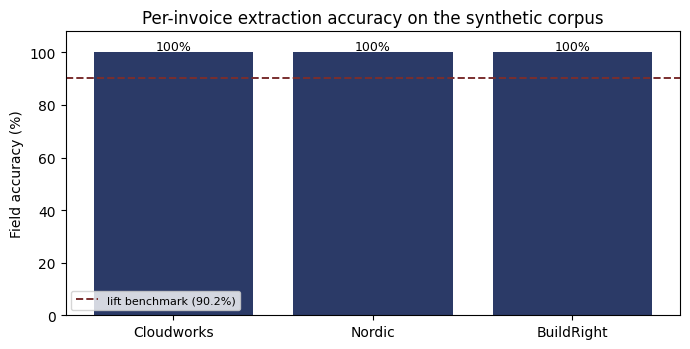


STEP 7/7 · (skipped) set RUN_ON_REAL_PDF = True and REAL_PDF_URL to mine your own invoice.

✅ Done. You now have: schema-valid invoice extractions, a scored grade, and an AP ledger.
   Next: swap in your own invoice PDFs + tweak SCHEMA, or reuse MODEL across thousands of files.


In [1]:
print("STEP 5/7 · Assembling the extractions into a queryable accounts-payable ledger")
print("=" * 90)

def g(d, path, default=None):
    cur = d
    for key in path.split("."):
        if isinstance(cur, dict) and cur.get(key) is not None:
            cur = cur[key]
        else:
            return default
    return cur

kb = pd.DataFrame([{
    "invoice":    g(r["pred"], "invoice_number"),
    "vendor":     g(r["pred"], "vendor.name"),
    "customer":   g(r["pred"], "customer_name"),
    "ccy":        g(r["pred"], "currency"),
    "total":      g(r["pred"], "total_amount"),
    "paid":       g(r["pred"], "amount_paid"),
    "balance":    g(r["pred"], "balance_due"),
    "is_paid":    g(r["pred"], "is_paid"),
    "items":      len(g(r["pred"], "line_items", []) or []),
    "po":         g(r["pred"], "purchase_order_number"),
    "field_acc":  round(r["acc"], 3),
} for r in results])

print("\nAccounts-payable ledger one row per mined invoice:\n")
print(kb.to_string(index=False))

print("\nExample query — OUTSTANDING invoices not fully paid, largest balance first:\n")
owed = kb[kb["is_paid"] != True].sort_values("balance", ascending=False)
print(owed.to_string(index=False) if len(owed) else "  everything is paid 🎉")

try:
    total_owed = sum((r or 0) for r in kb.loc[kb["is_paid"] != True, "balance"])
    print(f"\nTotal outstanding across the batch: {total_owed:,.2f} mixed currencies — group by ccy in practice")
except Exception:
    pass

overall = sum(r["acc"] for r in results) / len(results)
print(f"\nSTEP 6/7 · Overall field accuracy across {len(results)} invoices: {overall*100:.1f}%")
print("     Datalab report lift at ~90.2% field accuracy on their 225-doc benchmark.")


try:
    import matplotlib.pyplot as plt
    labels = [r["src"]["vendor_name"].split()[0] for r in results]
    accs   = [r["acc"] * 100 for r in results]
    plt.figure(figsize=(7, 3.6))
    bars = plt.bar(labels, accs, color="#2b3a67")
    plt.axhline(90.2, ls="--", color="#7a2e2e", lw=1.4, label="lift benchmark 90.2%")
    for b, a in zip(bars, accs):
        plt.text(b.get_x() + b.get_width()/2, a + 1, f"{a:.0f}%", ha="center", fontsize=9)
    plt.ylim(0, 108); plt.ylabel("Field accuracy %")
    plt.title("Per-invoice extraction accuracy on the synthetic corpus")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()
except Exception as e:
    print("     chart skipped:", e, ")")


if RUN_ON_REAL_PDF and REAL_PDF_URL:
    print("\n" + "=" * 90)
    print(f"STEP 7/7 · Bonus — extracting from a REAL invoice: {REAL_PDF_URL}")
    print("=" * 90)
    try:
        import urllib.request
        real_path = "/content/real_invoice.pdf" if os.path.isdir("/content") else "real_invoice.pdf"
        urllib.request.urlretrieve(REAL_PDF_URL, real_path)
        pred_real = run_lift(real_path, SCHEMA, page_range=REAL_PDF_PAGES)
        print("\nExtraction no ground truth — real invoices vary wildly in layout:\n")
        print(json.dumps(pred_real, indent=2, ensure_ascii=False))
        print("\nTip: real invoices differ hugely by vendor. Tighten the field `description`s and use "
              "page_range to point lift at the page that carries the totals block.")
    except Exception as e:
        print("     real-PDF pass failed:", e)
else:
    print("\nSTEP 7/7 · skipped set RUN_ON_REAL_PDF = True and REAL_PDF_URL to mine your own invoice.")

print("\n✅ Done. You now have: schema-valid invoice extractions, a scored grade, and an AP ledger.")
print("   Next: swap in your own invoice PDFs + tweak SCHEMA, or reuse MODEL across thousands of files.")